![imagen](https://cdn.foodbeast.com/content/wp-content/uploads/2012/03/beer-print-01-selectism.jpg)

# Ejercicio pandas estadística
Para este ejercicio se ha utilizado [un dataset de un concurso de kaggle](https://www.kaggle.com/nickhould/craft-cans), cuyo reto consiste en predecir el tipo de cerveza en función de sus características (nivel de alcohol, amargura, tamaño...).

# Ejercicio 1
Importa las librerias que consideres

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Ejercicio 2
1. Importa el dataset "datasets_beer.csv"
2. Imprime por pantalla los primeros registros.
3. ¿Cuáles son sus columnas?
4. ¿Qué dimensiones tiene el DataFrame?

In [53]:
beer = pd.read_csv(r'C:\Users\cchia\Desktop\Ejercicios y apuntes\Mi Carpeta\2026-02-BILBAO-FT-Data-Science\2-Data_Analysis\2-Pandas\Practica\6-Beers\data\datasets_beers.csv')
# la r es para que no haya problemas con las barras de la ruta

In [54]:
beer.head()

,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0


In [55]:
beer.columns

Index(['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id',
       'ounces'],
      dtype='str')

In [56]:
beer.shape

(2410, 8)

## Ejercicio 3
[Elimina la columna "Unnamed: 0"](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

In [57]:
beer.drop("Unnamed: 0", axis=1, inplace=True)

In [58]:
beer

,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0


## Ejercicio 4
¿Cuántas filas y columnas tiene el dataset?

In [59]:
beer.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


In [60]:
beer.shape

(2410, 7)

## Ejercicio 5
¿De qué tipo son los datos?

In [61]:
beer.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


## Ejercicio 6
Obtén en un nuevo DataFrame un resumen con las principales estadísticas de las columnas numéricas: mean, max, count, cuartiles...

In [62]:
beer_statistics = beer.describe().T
beer_statistics

,count,mean,std,min,25%,50%,75%,max
abv,2348.0,0.059773,0.013542,0.001,0.05,0.056,0.067,0.128
ibu,1405.0,42.713167,25.954066,4.000,21.00,35.000,64.000,138.000
id,2410.0,1431.113278,752.459975,1.000,808.25,1453.500,2075.750,2692.000
brewery_id,2410.0,231.749793,157.685604,0.000,93.00,205.000,366.000,557.000
ounces,2410.0,13.592241,2.352204,8.400,12.00,12.000,16.000,32.000


## Ejercicio 7
¿Cuántas birras hay de cada estilo en este dataset? [Investiga en la documentación de Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html) si puedes hacer un conteo de valores.

In [63]:
beer["style"].value_counts() # importante poner los paréntesis

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
American Malt Liquor                1
Grisette                            1
Flanders Oud Bruin                  1
Braggot                             1
Low Alcohol Beer                    1
Name: count, Length: 99, dtype: int64

In [64]:
beer.groupby("style").count()[["name"]].sort_values(by="name", ascending=False)

,name
style,
American IPA,424
American Pale Ale (APA),245
American Amber / Red Ale,133
American Blonde Ale,108
American Double / Imperial IPA,105
...,...
Kristalweizen,1
Other,1
Low Alcohol Beer,1


## Ejercicio 8
1. Imprime por pantalla los registros desde el décimo hasta el vigésimo
2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
4. Convierte el resultado del apartado 3 en un array de `numpy`

In [65]:
beer[10:21]

,abv,ibu,id,name,style,brewery_id,ounces
10,0.072,NaN,2099,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,0.073,NaN,2098,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,0.069,NaN,2097,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,0.085,NaN,1980,Troll Destroyer,Belgian IPA,177,12.0
14,0.061,60.0,1979,Bitter Bitch,American Pale Ale (APA),177,12.0
15,0.060,NaN,2318,Ginja Ninja,Cider,154,12.0
16,0.060,NaN,2170,Cherried Away,Cider,154,12.0
17,0.060,NaN,2169,Rhubarbarian,Cider,154,12.0
18,0.060,NaN,1502,BrightCider,Cider,154,12.0
19,0.082,NaN,1593,He Said Baltic-Style Porter,Baltic Porter,368,12.0


In [66]:
beer.loc[10:20, "name":"ounces"] # loc también incluye la fila 20

,name,style,brewery_id,ounces
10,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,Troll Destroyer,Belgian IPA,177,12.0
14,Bitter Bitch,American Pale Ale (APA),177,12.0
15,Ginja Ninja,Cider,154,12.0
16,Cherried Away,Cider,154,12.0
17,Rhubarbarian,Cider,154,12.0
18,BrightCider,Cider,154,12.0
19,He Said Baltic-Style Porter,Baltic Porter,368,12.0


In [67]:
beer[10:21][["abv", "ibu", "ounces"]]

,abv,ibu,ounces
10,0.072,NaN,12.0
11,0.073,NaN,12.0
12,0.069,NaN,12.0
13,0.085,NaN,12.0
14,0.061,60.0,12.0
15,0.060,NaN,12.0
16,0.060,NaN,12.0
17,0.060,NaN,12.0
18,0.060,NaN,12.0
19,0.082,NaN,12.0


In [68]:
beer_array_np = np.array(beer[10:21][["abv", "ibu", "ounces"]])

In [69]:
beer_array_np

array([[ 0.072,    nan, 12.   ],
       [ 0.073,    nan, 12.   ],
       [ 0.069,    nan, 12.   ],
       [ 0.085,    nan, 12.   ],
       [ 0.061, 60.   , 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.06 ,    nan, 12.   ],
       [ 0.082,    nan, 12.   ],
       [ 0.082,    nan, 12.   ]])

## Ejercicio 9
¿Cuántas onzas pesan todas las birras del dataset?

In [70]:
print(beer["ounces"].sum())

32757.3


## Ejercicio 10
El amargor de las cervezas se mide por su nivel de IBUs.
1. ¿Cuál es el amargor medio de las cervezas?
2. ¿El máximo? ¿Y el mínimo?
3. ¿Qué cerveza es la que tiene el amargor máximo? ¿Cuál es la de amargor mínimo?

In [71]:
beer["ibu"].aggregate(["mean", "max", "min"])

mean     42.713167
max     138.000000
min       4.000000
Name: ibu, dtype: float64

In [72]:
beer["name"][beer["ibu"].idxmax()] # solo devuelve la primera

'Bitter Bitch Imperial IPA'

In [73]:
beer.iloc[beer["ibu"].idxmax()][["name", "ibu"]]

name    Bitter Bitch Imperial IPA
ibu                         138.0
Name: 147, dtype: object

In [74]:
beer[["name", "ibu"]][beer["ibu"] == beer["ibu"].max()] # para coger todas las que tengan el amargor máximo

,name,ibu
147,Bitter Bitch Imperial IPA,138.0


In [75]:
beer["name"][beer["ibu"].idxmin()] # solo devuelve la primera

'Summer Solstice'

In [76]:
beer[["name", "ibu"]][beer["ibu"] == beer["ibu"].min()] # para coger todas las que tengan el amargor mínimo

,name,ibu
106,Summer Solstice,4.0
112,Summer Solstice Cerveza Crema (2009),4.0
117,Summer Solstice (2011),4.0


## Ejercicio 11
No queda muy claro cuánto de dispar, de dispersa, es la medida de IBU. Mediante estadística descriptiva (una o dos métricas, sin gráficas), razona la dispersión de la variable IBU.

In [77]:
print(beer["ibu"].mean())
print(beer["ibu"].var()) # La varianza es muy elevada, lo que indica que los datos están muy dispersos
print(beer["ibu"].std()) # La desviación típica es de 25.95 unidades de distancia respecto de la media

42.71316725978647
673.6135373259929
25.954065911259317


## Ejercicio 12
¿Existe alguna relación lineal entre las variables numéricas del dataset? Intenta pintar este razonamiento mediante un gráfico

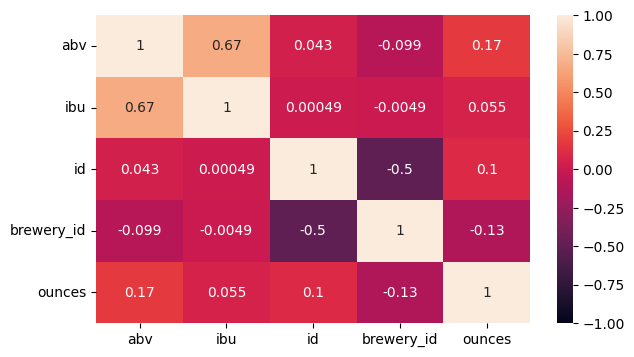

In [78]:
plt.figure(figsize=(7, 4))
sns.heatmap(beer[["abv", "ibu", "id", "brewery_id", "ounces"]].corr(), annot = True, vmin = -1, vmax = 1)
plt.show()
# los id no se meten
# No hay variables con relación lineal fuerte; las dos con mayor relación son "abv" e "ibu" (0.67)

## Ejercicio 13
Representa el nivel de alcohol (columna `abv`) en un histograma. ¿Se trata de una distribución simétrica o asimétrica?

Skew: 0.96


<Axes: >

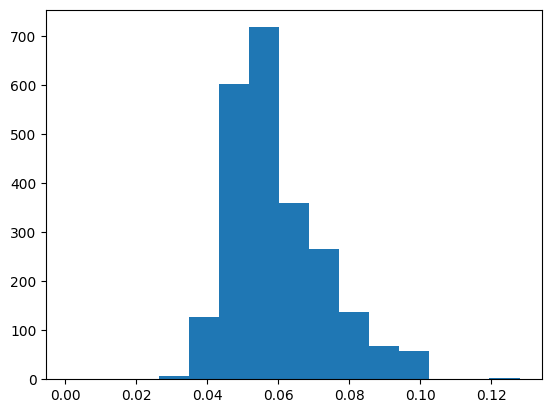

In [79]:
print('Skew:', round(beer["abv"].skew(), 2))
beer["abv"].hist(grid=False, bins=15)
# Es una distribución asimétrica positiva, con una cola larga hacia la derecha

## Ejercicio 14
Representa mediante un *boxplot* de `seaborn` la variable `abv`

<Axes: ylabel='abv'>

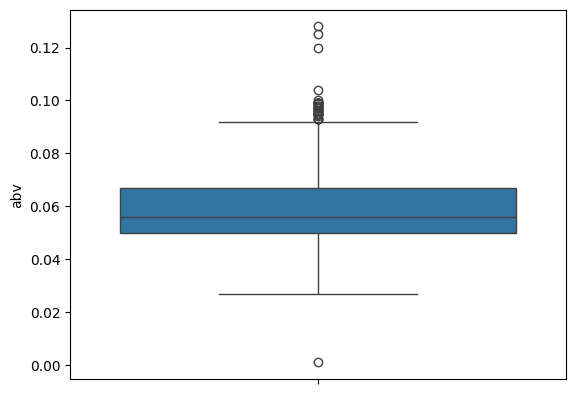

In [80]:
sns.boxplot(beer["abv"])

## Ejercicio 15
1. ¿Qué estilos son los que tienen en media más alcohol?
2. ¿Y los estilos que son en media más amargos?

In [81]:
beer.groupby("style")["abv"].mean().sort_values(ascending=False)

style
English Barleywine        0.107667
Quadrupel (Quad)          0.104000
American Barleywine       0.099000
American Malt Liquor      0.099000
Russian Imperial Stout    0.097636
                            ...   
Berliner Weissbier        0.043909
English Dark Mild Ale     0.041500
Light Lager               0.040417
Radler                    0.040333
Low Alcohol Beer          0.001000
Name: abv, Length: 99, dtype: float64

In [82]:
beer.groupby("style")["ibu"].mean().sort_values(ascending=False)

style
American Barleywine                   96.00
American Double / Imperial IPA        93.32
Russian Imperial Stout                86.50
American Double / Imperial Pilsner    85.00
Belgian Strong Dark Ale               72.00
                                      ...  
Kristalweizen                           NaN
Low Alcohol Beer                        NaN
Mead                                    NaN
Rauchbier                               NaN
Shandy                                  NaN
Name: ibu, Length: 99, dtype: float64

In [83]:
"""NO ES ESTO LO QUE PEDÍA, PERO LO DEJO PARA APRENDER:
Para “ordenar X según Y”: df.sort_values("Y")["X"]
>> MAL: beer["style"][beer["abv"].sort_values(ascending=False)]
>> BIEN: beer.sort_values("abv", ascending=False)[["abv", "style"]] # pongo ambos para que se impriman los dos
"""
print()

## Ejercicio 16
Carga el datasets de cervecerias `datasets_breweries.csv`

In [84]:
breweries = pd.read_csv(r"C:\Users\cchia\Desktop\Ejercicios y apuntes\Mi Carpeta\2026-02-BILBAO-FT-Data-Science\2-Data_Analysis\2-Pandas\Practica\6-Beers\data\datasets_breweries.csv")
breweries

,Unnamed: 0,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 17
1. Renombra la columna `Unnamed: 0` como `brewery_id`
2. Renombra también la columna `name` por `brewery_name`. ¿Puedes hacer ambos apartados en una sola sentencia?

In [85]:
breweries.rename(columns={"Unnamed: 0" : "brewery_id", "name" : "brewery_name"}, inplace=True)
breweries

,brewery_id,brewery_name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 18
Junta los dos datasets que tienes

In [86]:
beer.nunique() # Hay 558 brewery_id, concuerda con "breweries" y lo uno en base a esta columna

abv             74
ibu            107
id            2410
name          2305
style           99
brewery_id     558
ounces           7
dtype: int64

In [87]:
beer_breweries = pd.merge(beer, breweries, on= "brewery_id", how= "outer")
# los NaN se guardaban igual porque el "how" solo afecta a la columna de cruce (brewery_id)
beer_breweries

,abv,ibu,id,name,style,brewery_id,ounces,brewery_name,city,state
0,0.045,50.0,2692,Get Together,American IPA,0,16.0,NorthGate Brewing,Minneapolis,MN
1,0.049,26.0,2691,Maggie's Leap,Milk / Sweet Stout,0,16.0,NorthGate Brewing,Minneapolis,MN
2,0.048,19.0,2690,Wall's End,English Brown Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
3,0.060,38.0,2689,Pumpion,Pumpkin Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
4,0.060,25.0,2688,Stronghold,American Porter,0,16.0,NorthGate Brewing,Minneapolis,MN
...,...,...,...,...,...,...,...,...,...,...
2405,0.049,NaN,52,Heinnieweisse Weissebier,Hefeweizen,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2406,0.068,NaN,51,Snapperhead IPA,American IPA,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2407,0.049,NaN,50,Moo Thunder Stout,Milk / Sweet Stout,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2408,0.043,NaN,49,Porkslap Pale Ale,American Pale Ale (APA),556,12.0,Butternuts Beer and Ale,Garrattsville,NY


In [88]:
beer_breweries.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   abv           2348 non-null   float64
 1   ibu           1405 non-null   float64
 2   id            2410 non-null   int64  
 3   name          2410 non-null   str    
 4   style         2405 non-null   str    
 5   brewery_id    2410 non-null   int64  
 6   ounces        2410 non-null   float64
 7   brewery_name  2410 non-null   str    
 8   city          2410 non-null   str    
 9   state         2410 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 188.4 KB


## Ejercicio 19
1. ¿Cuántos estados diferentes hay?
2. ¿Y ciudades diferentes?
3. ¿Cuántas cervecerías hay?

In [89]:
beer_breweries[["state", "city", "brewery_name", "brewery_id"]].nunique()
# Curioso que hay 551 cervecerías por nombre, y 558 por id, cuando no hay nulls en ninguna

state            51
city            384
brewery_name    551
brewery_id      558
dtype: int64

In [93]:
beer_breweries[beer_breweries["brewery_name"].duplicated()]["brewery_name"].unique()

<StringArray>
[                 'NorthGate Brewing ',           'Against the Grain Brewery',
            'Jack's Abby Craft Lagers',           'Mike Hess Brewing Company',
             'Fort Point Beer Company',               'COAST Brewing Company',
        'Great Divide Brewing Company',                    'Tapistry Brewing',
                    'Big Lake Brewing',                      'Brewery Vivant',
 ...
        'Angry Minnow Brewing Company',      'Great Northern Brewing Company',
                   'Pyramid Breweries',           'Lancaster Brewing Company',
             'Upstate Brewing Company', 'Moat Mountain Smoke House & Brew...',
            'Prescott Brewing Company',          'Wind River Brewing Company',
                   'Silverton Brewery',             'Butternuts Beer and Ale']
Length: 431, dtype: str

## Ejercicio 20
Agrupa por estado y ciudad, la media, mediana y máximo nivel de alcohol

In [94]:
beer_breweries.groupby(["state", "city"])["abv"].aggregate(["mean", "median", "max"])

mean  median    max
state city                               
AK    Anchorage   0.054200  0.0520  0.063
      Juneau      0.053000  0.0530  0.053
      Soldotna    0.058500  0.0580  0.068
      Talkeetna   0.059500  0.0585  0.065
AL    Birmingham  0.065400  0.0600  0.093
...                    ...     ...    ...
WI    Wilson      0.055000  0.0550  0.055
WV    Lewisburg   0.062000  0.0620  0.067
WY    Jackson     0.054857  0.0520  0.068
      Pinedale    0.061000  0.0610  0.072
      Sheridan    0.052833  0.0480  0.070

[401 rows x 3 columns]

## Ejercicio 21
¿Cuáles son las cervezas más amargas que se consumen en Indiana, estado = `IN`?

In [95]:
beer_breweries["state"].unique()

<StringArray>
[' MN', ' KY', ' MA', ' CA', ' SC', ' CO', ' MI', ' IN', ' TX', ' AZ', ' MO',
 ' WI', ' IL', ' VT', ' ME', ' PA', ' KS', ' NY', ' NH', ' GA', ' VA', ' FL',
 ' MD', ' NC', ' WY', ' OR', ' RI', ' CT', ' OH', ' AK', ' MS', ' AR', ' LA',
 ' WV', ' UT', ' ID', ' WA', ' OK', ' NE', ' HI', ' IA', ' SD', ' NJ', ' MT',
 ' DC', ' NV', ' TN', ' NM', ' AL', ' DE', ' ND']
Length: 51, dtype: str

In [ ]:
beer_breweries[beer_breweries["state"].str.strip()=="IN"]["ibu"].sort_values(ascending=False)
#str.strip() función sobre strings que te quita los espacios que haya antes y después

145     115.0
166     115.0
140     104.0
203      91.0
160      90.0
        ...  
1628      NaN
1629      NaN
1727      NaN
1754      NaN
2289      NaN
Name: ibu, Length: 139, dtype: float64

In [98]:
beer_breweries.loc[beer_breweries["state"].str.strip()=="IN"]

,abv,ibu,id,name,style,brewery_id,ounces,brewery_name,city,state
138,0.065,NaN,2624,Deflator,Doppelbock,16,16.0,Flat 12 Bierwerks,Indianapolis,IN
139,0.050,27.0,2284,Hinchtown Hammer Down,American Blonde Ale,16,16.0,Flat 12 Bierwerks,Indianapolis,IN
140,0.060,104.0,1610,Half Cycle IPA,American IPA,16,16.0,Flat 12 Bierwerks,Indianapolis,IN
141,0.058,20.0,2623,Cafe Leche,American Porter,17,16.0,Tin Man Brewing Company,Evansville,IN
142,0.052,12.0,2622,Damascene Apricot Sour,Fruit / Vegetable Beer,17,16.0,Tin Man Brewing Company,Evansville,IN
...,...,...,...,...,...,...,...,...,...,...
1628,0.080,NaN,1787,Floyd's Folly,Scottish Ale,315,16.0,Cutters Brewing Company,Avon,IN
1629,0.063,NaN,1786,Half Court IPA,American IPA,315,16.0,Cutters Brewing Company,Avon,IN
1727,0.040,NaN,1657,Leprechaun Lager,American Pale Lager,348,12.0,Four Horsemen Brewing Company,South Bend,IN
1754,0.072,NaN,1623,Lift Off IPA,American IPA,358,16.0,Daredevil Brewing Company,Shelbyville,IN


## Ejercicio 22
Obtén una tabla con los principales estadísticos del campo `ibu`,  a nivel ciudad

In [99]:
beer_breweries.groupby("city")["ibu"].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Abingdon,1.0,135.000000,NaN,135.0,135.00,135.0,135.00,135.0
Abita Springs,3.0,27.333333,21.455380,13.0,15.00,17.0,34.50,52.0
Ada,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afton,4.0,43.000000,19.899749,22.0,28.00,45.0,60.00,60.0
Airway Heights,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
Woodinville,4.0,46.750000,18.643587,27.0,39.75,44.0,51.00,72.0
Worcester,1.0,69.000000,NaN,69.0,69.00,69.0,69.00,69.0
Yakima,2.0,54.000000,22.627417,38.0,46.00,54.0,62.00,70.0


## Ejercicio 23
Consigue en un DataFrame de todas las cervezas en cuyas cervecerías al menos haya una cerveza con un `abv` mínimo 0.07.

In [ ]:
# Creo que pide esto; el enunciado está un poco mal formulado
beer_breweries[["brewery_name", "name", "abv"]][beer_breweries["abv"] >= 0.07]

,brewery_name,name,abv
6,Against the Grain Brewery,Citra Ass Down,0.080
7,Against the Grain Brewery,London Balling,0.125
8,Against the Grain Brewery,35 K,0.077
14,Against the Grain Brewery,Rico Sauvin,0.076
21,Jack's Abby Craft Lagers,Excess IPL,0.072
...,...,...,...
2331,Triangle Brewing Company,Triangle Belgian Golden Ale,0.080
2343,Buckbean Brewing Company,Tour de Nez Belgian IPA (Current),0.080
2345,Buckbean Brewing Company,Black Adder IBA (Current),0.073
2346,Buckbean Brewing Company,Very Noddy Lager (Current),0.099


In [104]:
ej23 = beer_breweries["brewery_name"][beer_breweries["abv"] >= 0.07].unique()
ej23

<StringArray>
[   'Against the Grain Brewery',     'Jack's Abby Craft Lagers',
    'Mike Hess Brewing Company',        'COAST Brewing Company',
 'Great Divide Brewing Company',             'Tapistry Brewing',
             'Big Lake Brewing',               'Brewery Vivant',
           'Blackrocks Brewery',     'Founders Brewing Company',
 ...
     'Mudshark Brewing Company',              'Wingman Brewers',
     'Monkey Paw Pub & Brewery',     'Crabtree Brewing Company',
           'Flying Dog Brewery',             'Uncommon Brewers',
        'Aspen Brewing Company',     'Triangle Brewing Company',
     'Buckbean Brewing Company',   'Wind River Brewing Company']
Length: 225, dtype: str

In [ ]:
beer_breweries[beer_breweries["brewery_name"].isin(ej23)][["brewery_name", "name", "abv"]]
#si una cervecería tiene al menos una cerveza con un abv>0.07, imprime el listado de todas las cervezas de esa cervecería

,brewery_name,name,abv
6,Against the Grain Brewery,Citra Ass Down,0.080
7,Against the Grain Brewery,London Balling,0.125
8,Against the Grain Brewery,35 K,0.077
9,Against the Grain Brewery,A Beer,0.042
10,Against the Grain Brewery,Rules are Rules,0.050
...,...,...,...
2347,Buckbean Brewing Company,Tule Duck Red Ale (Current),0.062
2348,Buckbean Brewing Company,Original Orange Blossom Ale (Current),0.058
2349,Buckbean Brewing Company,Black Noddy Lager (Current),0.052
2396,Wind River Brewing Company,Wyoming Pale Ale,0.072


## Ejercicio 24
Teniendo en cuenta la media de amargor de todas las cervezas, obtén una tabla con las cervezas cuyos estados tengan una media de amargor en cerveza por encima de la media

In [125]:
media_amargor = beer_breweries["ibu"].mean()
media_amargor

np.float64(42.71316725978647)

In [128]:
media_estados = beer_breweries.groupby("state")["ibu"].mean()

In [137]:
ej24_1 = media_estados[media_estados > media_amargor].index
ej24_1

Index([' AL', ' CA', ' CO', ' DC', ' DE', ' FL', ' GA', ' ID', ' IN', ' ME',
       ' MN', ' MS', ' NC', ' NH', ' NJ', ' NM', ' NV', ' NY', ' OH', ' OR',
       ' UT', ' VA', ' WA', ' WV'],
      dtype='str', name='state')

In [136]:
beer_breweries[beer_breweries["state"].isin(ej24_1)]

,abv,ibu,id,name,style,brewery_id,ounces,brewery_name,city,state
0,0.045,50.0,2692,Get Together,American IPA,0,16.0,NorthGate Brewing,Minneapolis,MN
1,0.049,26.0,2691,Maggie's Leap,Milk / Sweet Stout,0,16.0,NorthGate Brewing,Minneapolis,MN
2,0.048,19.0,2690,Wall's End,English Brown Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
3,0.060,38.0,2689,Pumpion,Pumpkin Ale,0,16.0,NorthGate Brewing,Minneapolis,MN
4,0.060,25.0,2688,Stronghold,American Porter,0,16.0,NorthGate Brewing,Minneapolis,MN
...,...,...,...,...,...,...,...,...,...,...
2404,0.055,NaN,98,Pilsner Ukiah,German Pilsener,555,12.0,Ukiah Brewing Company,Ukiah,CA
2405,0.049,NaN,52,Heinnieweisse Weissebier,Hefeweizen,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2406,0.068,NaN,51,Snapperhead IPA,American IPA,556,12.0,Butternuts Beer and Ale,Garrattsville,NY
2407,0.049,NaN,50,Moo Thunder Stout,Milk / Sweet Stout,556,12.0,Butternuts Beer and Ale,Garrattsville,NY


In [ ]:
# esto es una máscara de lista de estados con true o false; esto se aplica sobre el listado de estados
ej24 = beer_breweries.groupby("state")["ibu"].mean() > beer_breweries["ibu"].mean() # = media_amargor
# decirle qué hacer después del groupby: ["ibu"].mean()

51

In [142]:
# no funciona porque el orden de los estados no es el mismo en beer_breweries y ej24
# beer_breweries["state"].unique()[ej24]
